<a href="https://colab.research.google.com/github/shubham0328-pack/student-performance-analysis/blob/main/notebooks/student_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
from google.colab import files
uploaded = files.upload()

Saving student-mat.csv to student-mat (2).csv


In [54]:
df = pd.read_csv("student-mat.csv", sep=';')

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [55]:
df.shape


(395, 33)

In [56]:
df.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


In [57]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [58]:
df = df.drop_duplicates()

In [59]:
df.shape

(395, 33)

In [60]:
print(df.shape)
print(df.columns)
df.head()

(395, 33)
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [61]:
avg_grade = df["G3"].mean()

print("Average Final Grade:", avg_grade)

Average Final Grade: 10.415189873417722


In [62]:
print(df.columns)


Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [63]:
high_scores = df[df['G3'] > 15]

print("Number of students scoring above 15:", len(high_scores))

Number of students scoring above 15: 40


In [64]:
df[['studytime','G3']].corr()

,studytime,G3
studytime,1.00000,0.09782
G3,0.09782,1.00000


In [65]:
gender_avg = df.groupby('sex')['G3'].mean()

print(gender_avg)

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


In [66]:
top_students = df.sort_values(by='G3', ascending=False).head(10)

top_students[['sex','studytime','G3']]

,sex,studytime,G3
47,M,4,20
286,F,3,19
374,F,3,19
110,M,1,19
8,M,2,19
113,M,1,19
91,F,1,18
42,M,2,18
36,M,3,18
104,M,2,18


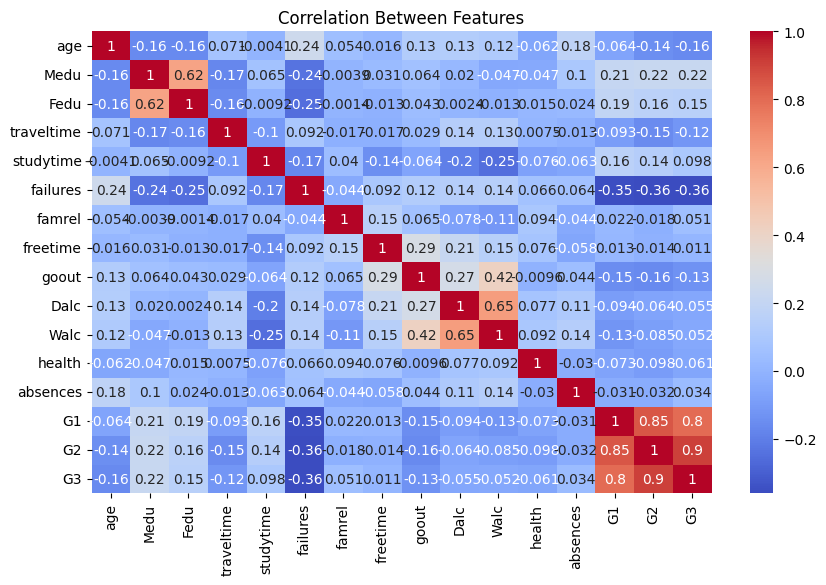

In [67]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Between Features")

plt.show()

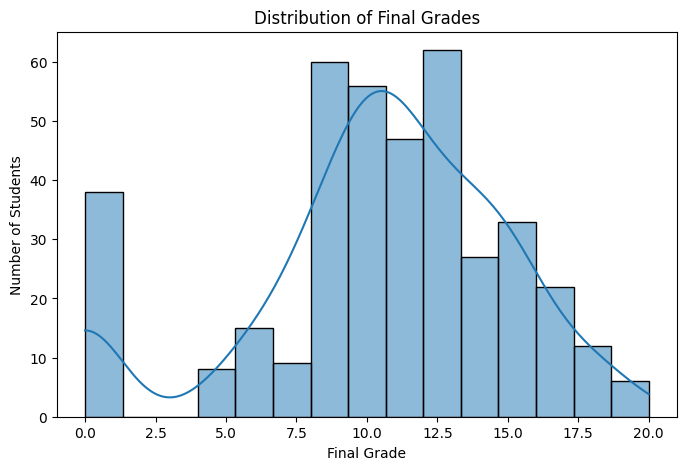

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(df['G3'], bins=15, kde=True)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.show()

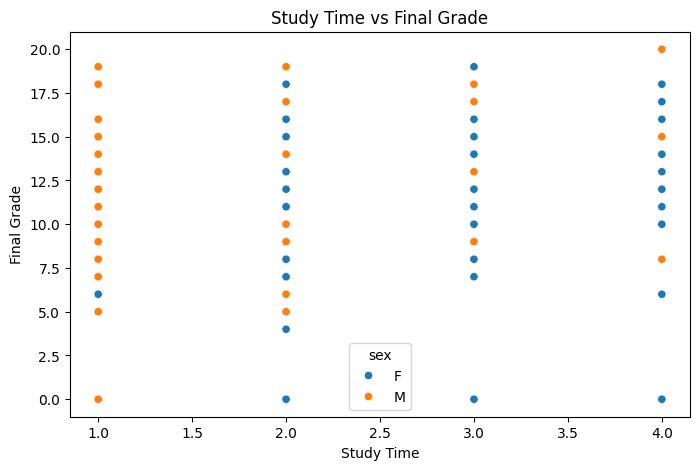

In [36]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='studytime', y='G3', data=df, hue='sex')

plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade")

plt.show()

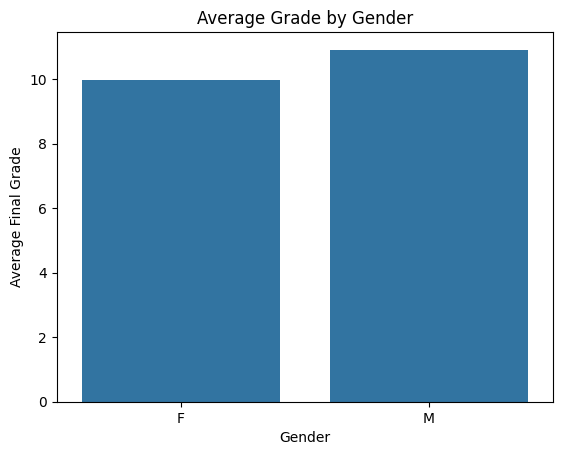

In [37]:
gender_avg = df.groupby('sex')['G3'].mean().reset_index()

sns.barplot(x='sex', y='G3', data=gender_avg)

plt.title("Average Grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Final Grade")

plt.show()

In [38]:
high_scorers = df[df['G3'] > 15]

print(f"🎯 Students scoring above 15: {len(high_scorers)}")
print(f"📈 Percentage of high performers: {(len(high_scorers)/len(df))*100:.2f}%")


🎯 Students scoring above 15: 40
📈 Percentage of high performers: 10.13%


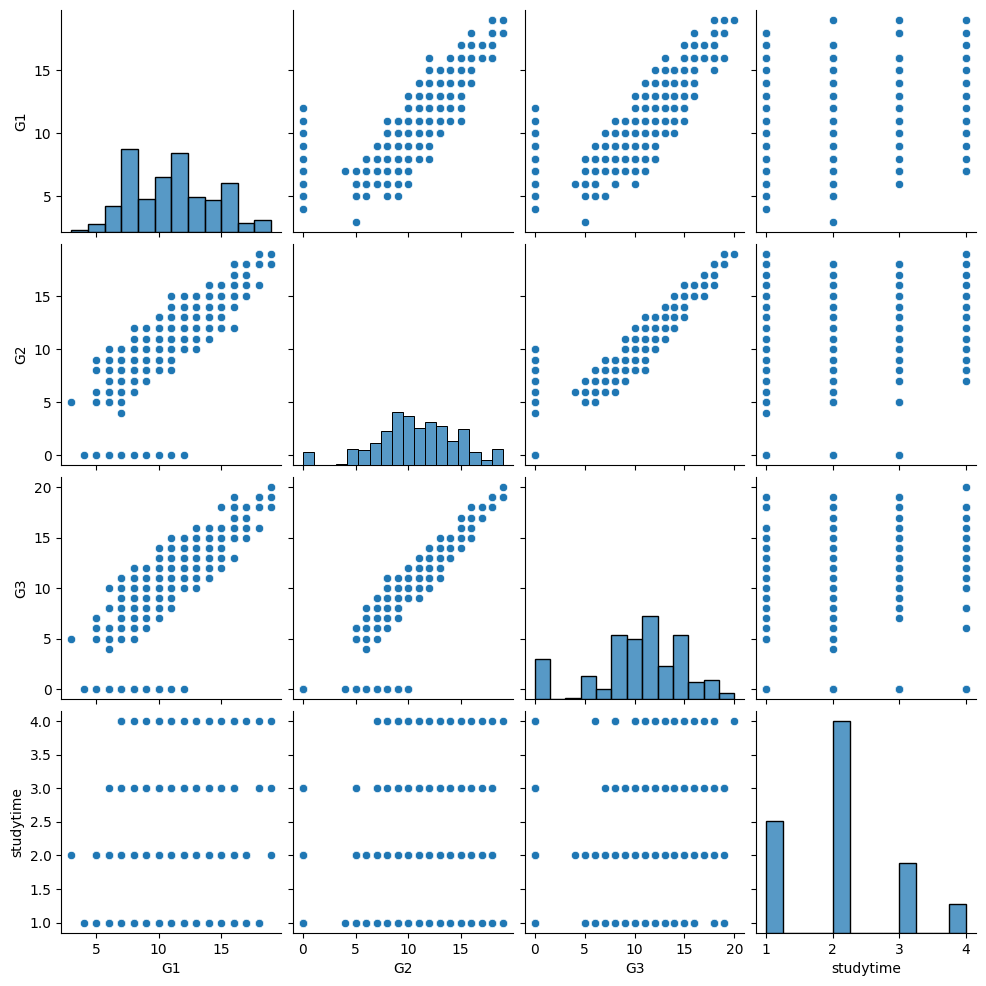

In [39]:
sns.pairplot(df[['G1','G2','G3','studytime']])
plt.show()

In [40]:
features = df[['studytime','failures','absences','G1','G2']]
target = df['G3']

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

In [42]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [43]:
predictions = model.predict(X_test)

In [44]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 1.3394159082670907
R2 Score: 0.7821754247320557


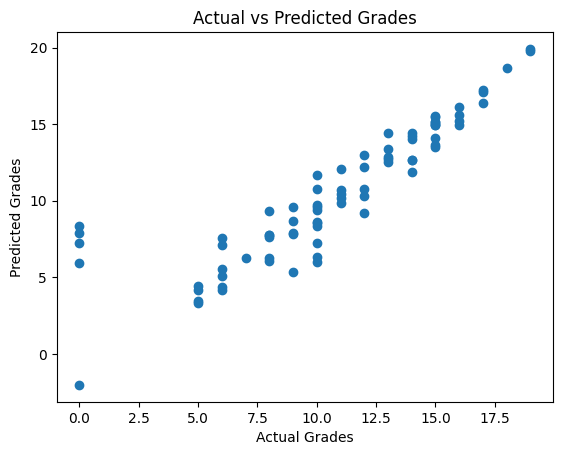

In [45]:
plt.scatter(y_test, predictions)

plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")

plt.title("Actual vs Predicted Grades")

plt.show()

In [68]:
import plotly.express as px

fig = px.histogram(df, x="G3", nbins=15,
                   title="Interactive Grade Distribution")

fig.show()

In [50]:
fig = px.scatter(df,
                 x="studytime",
                 y="G3",
                 color="sex",
                 title="Study Time vs Final Grades")

fig.show()